In [1]:
import pandas as pd
import numpy as np
import math
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats

https://stackoverflow.com/questions/29206384/python-folder-names-in-the-directory
https://softhints.com/how-to-merge-multiple-csv-files-with-python/#:~:text=Steps%20to%20merge%20multiple%20CSV%20%28identical%29%20files%20with,files%20in%20the%20list%20and%20export%20as%20CSV

In [2]:
import os

path = '../data/AReM'
folder_list=[]
folder_list = os.listdir(path)


In [3]:
folder_list.pop(2)
folder_list.pop(4)

'sensorsPlacement.pdf'

In [4]:
print(folder_list)

['bending1', 'bending2', 'cycling', 'lying', 'sitting', 'standing', 'walking']


In [5]:
df_test = []

In [6]:
df_time_features=pd.DataFrame(columns=['movement','mean1','std1','min1','1st Quart(1)','Median(1)','3rd Quart(1)','max1','mean2','std2','min2','1st Quart(2)','Median(2)','3rd Quart(2)','max2','mean3','std3','min3','1st Quart(3)','Median(3)','3rd Quart(3)','max3','mean4','std4','min4','1st Quart(4)','Median(4)','3rd Quart(4)','max4','mean5','std5','min5','1st Quart(5)','Median(5)','3rd Quart(5)','max5','mean6','std6','min6','1st Quart(6)','Median6','3rd Quart(6)','max6'])

In [7]:
headers = ["# Columns: time",  "avg_rss12",  "var_rss12",  "avg_rss13",  "var_rss13",  "avg_rss23", "var_rss23","movement"]
for i in range(0,2):
    print(f'Folder: {i+1}\n')
    for j in range(0,2):
        temp = pd.read_csv('../data/AReM/'+folder_list[i]+'/dataset'+str(j+1)+'.csv', header=None,sep=',', skiprows = [0, 1, 2, 3, 4])
        temp[7]=folder_list[i]
        temp.columns= headers
#         if(len(temp)<480):
#             for i in range(0,480-len(temp)):
#                 temp.append([mean])
        print(folder_list[i],j, len(temp))
        ft_df = pd.DataFrame(temp.describe())
        ft_df = ft_df.iloc[1:,1:]
        ft_df =ft_df.T
        ft_arr=ft_df.to_numpy().flatten()
        ft_arr=np.concatenate(([1], ft_arr))
        df_time_features.loc[len(df_time_features)]=ft_arr
        df_test.append(temp)

Folder: 1

bending1 0 480
bending1 1 480
Folder: 2

bending2 0 480
bending2 1 480


In [8]:
len(temp)

480

In [9]:
df_test

[     # Columns: time  avg_rss12  var_rss12  avg_rss13  var_rss13  avg_rss23  \
 0                  0      39.25       0.43      22.75       0.43      33.75   
 1                250      39.25       0.43      23.00       0.00      33.00   
 2                500      39.25       0.43      23.25       0.43      33.00   
 3                750      39.50       0.50      23.00       0.71      33.00   
 4               1000      39.50       0.50      24.00       0.00      33.00   
 ..               ...        ...        ...        ...        ...        ...   
 475           118750      43.33       0.47      25.00       0.00      30.00   
 476           119000      43.50       0.50      25.50       0.50      30.00   
 477           119250      43.50       0.50      24.75       0.43      30.00   
 478           119500      43.50       0.50      24.33       0.47      30.00   
 479           119750      43.50       0.50      24.25       0.43      30.00   
 
      var_rss23  movement  
 0        

In [10]:
for i in range(2,len(folder_list)):
    path = '../data/AReM/'+folder_list[i]
    dataset_list = os.listdir(path)
    for j in range(0,3):
        temp = pd.read_csv('../data/AReM/'+folder_list[i]+'/dataset'+str(j+1)+'.csv', header=None,sep=',', skiprows = [0, 1, 2, 3, 4])
        temp[7]=folder_list[i]
        temp.columns= headers
        print(folder_list[i],j, len(temp))
        ft_df = pd.DataFrame(temp.describe())
        ft_df = ft_df.iloc[1:,1:]
        ft_df =ft_df.T
        ft_arr=ft_df.to_numpy().flatten()
        ft_arr=np.concatenate(([0], ft_arr))
        df_time_features.loc[len(df_time_features)]=ft_arr
        df_test.append(temp)

cycling 0 480
cycling 1 480
cycling 2 480
lying 0 480
lying 1 480
lying 2 480
sitting 0 480
sitting 1 480
sitting 2 480
standing 0 480
standing 1 480
standing 2 480
walking 0 480
walking 1 480
walking 2 480


In [11]:
merged_df_test = pd.concat(df_test, ignore_index=True)

In [12]:
merged_df_test

,# Columns: time,avg_rss12,var_rss12,avg_rss13,var_rss13,avg_rss23,var_rss23,movement
0,0,39.25,0.43,22.75,0.43,33.75,1.30,bending1
1,250,39.25,0.43,23.00,0.00,33.00,0.00,bending1
2,500,39.25,0.43,23.25,0.43,33.00,0.00,bending1
3,750,39.50,0.50,23.00,0.71,33.00,0.00,bending1
4,1000,39.50,0.50,24.00,0.00,33.00,0.00,bending1
...,...,...,...,...,...,...,...,...
9115,118750,36.00,2.45,17.00,5.10,20.50,0.87,walking
9116,119000,34.33,1.89,15.00,2.45,17.00,2.12,walking
9117,119250,33.00,7.35,14.60,3.14,13.00,5.70,walking
9118,119500,31.67,1.25,11.00,6.16,19.25,2.17,walking


In [13]:
df_train=[]

In [14]:
headers = ["# Columns: time",  "avg_rss12",  "var_rss12",  "avg_rss13",  "var_rss13",  "avg_rss23", "var_rss23","movement"]
for i in range(0,2):
    path = '../data/AReM/'+folder_list[i]
    dataset_list = os.listdir(path)
    for j in range(2,len(dataset_list)):
        print('../data/AReM/'+folder_list[i]+'/dataset'+str(j+1)+'.csv')
        temp = pd.read_csv('../data/AReM/'+folder_list[i]+'/dataset'+str(j)+'.csv', header=None,delimiter='[ ,]',skiprows = [0, 1, 2, 3, 4])
        temp[7]=folder_list[i]
        temp.columns= headers
        print(folder_list[i],j, len(temp))
        ft_df = pd.DataFrame(temp.describe())
        ft_df = ft_df.iloc[1:,1:]
        ft_df =ft_df.T
        ft_arr=ft_df.to_numpy().flatten()
        ft_arr=np.concatenate(([1], ft_arr))
        df_time_features.loc[len(df_time_features)]=ft_arr
        df_train.append(temp)

../data/AReM/bending1/dataset3.csv
bending1 2 480
../data/AReM/bending1/dataset4.csv
bending1 3 480
../data/AReM/bending1/dataset5.csv
bending1 4 480
../data/AReM/bending1/dataset6.csv
bending1 5 480
../data/AReM/bending1/dataset7.csv
bending1 6 480
../data/AReM/bending2/dataset3.csv
bending2 2 480
../data/AReM/bending2/dataset4.csv
bending2 3 480
../data/AReM/bending2/dataset5.csv
bending2 4 480
../data/AReM/bending2/dataset6.csv
bending2 5 480


C:\Users\Swatej Sonawane\AppData\Local\Temp\ipykernel_47488\3098102923.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  temp = pd.read_csv('../data/AReM/'+folder_list[i]+'/dataset'+str(j)+'.csv', header=None,delimiter='[ ,]',skiprows = [0, 1, 2, 3, 4])
C:\Users\Swatej Sonawane\AppData\Local\Temp\ipykernel_47488\3098102923.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  temp = pd.read_csv('../data/AReM/'+folder_list[i]+'/dataset'+str(j)+'.csv', header=None,delimiter='[ ,]',skiprows = [0, 1, 2, 3, 4])
C:\Users\Swatej Sonawane\AppData\Local\Temp\ipykernel_47488\3098102923.py:7: ParserWarning: Fallin

In [15]:
for i in range(2,len(folder_list)):
    path = '../data/AReM/'+folder_list[i]
    dataset_list = os.listdir(path)
    for j in range(3,len(dataset_list)):
        temp = pd.read_csv('../data/AReM/'+folder_list[i]+'/dataset'+str(j)+'.csv', header=None,sep=',',usecols=[0,1,2,3,4,5,6], skiprows = [0, 1, 2, 3, 4])
        temp[7]=folder_list[i]
        temp.columns=headers
        print(folder_list[i],j, len(temp))
        ft_df = pd.DataFrame(temp.describe())
        ft_df = ft_df.iloc[1:,1:]
        ft_df =ft_df.T
        ft_arr=ft_df.to_numpy().flatten()
        ft_arr=np.concatenate(([0], ft_arr))
        df_time_features.loc[len(df_time_features)]=ft_arr
        df_train.append(temp)

cycling 3 480
cycling 4 480
cycling 5 480
cycling 6 480
cycling 7 480
cycling 8 480
cycling 9 480
cycling 10 480
cycling 11 480
cycling 12 480
cycling 13 480
cycling 14 480
lying 3 480
lying 4 480
lying 5 480
lying 6 480
lying 7 480
lying 8 480
lying 9 480
lying 10 480
lying 11 480
lying 12 480
lying 13 480
lying 14 480
sitting 3 480
sitting 4 480
sitting 5 480
sitting 6 480
sitting 7 480
sitting 8 479
sitting 9 480
sitting 10 480
sitting 11 480
sitting 12 480
sitting 13 480
sitting 14 480
standing 3 480
standing 4 480
standing 5 480
standing 6 480
standing 7 480
standing 8 480
standing 9 480
standing 10 480
standing 11 480
standing 12 480
standing 13 480
standing 14 480
walking 3 480
walking 4 480
walking 5 480
walking 6 480
walking 7 480
walking 8 480
walking 9 480
walking 10 480
walking 11 480
walking 12 480
walking 13 480
walking 14 480


In [16]:
len(df_train)

69

In [17]:
merged_df_train = pd.concat(df_train, ignore_index=True)

In [18]:
merged_df_train

,# Columns: time,avg_rss12,var_rss12,avg_rss13,var_rss13,avg_rss23,var_rss23,movement
0,0,43.67,0.47,24.75,0.43,30.00,0.00,bending1
1,250,43.33,0.47,25.33,0.47,30.00,0.00,bending1
2,500,42.75,0.83,25.25,0.83,30.50,0.50,bending1
3,750,41.75,0.43,20.50,3.35,30.75,0.83,bending1
4,1000,42.50,0.50,20.75,4.55,31.75,0.43,bending1
...,...,...,...,...,...,...,...,...
33114,118750,39.33,0.47,10.00,2.16,7.00,4.85,walking
33115,119000,39.25,2.49,12.50,1.66,10.75,4.49,walking
33116,119250,40.00,8.22,15.75,2.05,14.00,4.42,walking
33117,119500,29.50,6.50,18.00,1.87,17.00,3.67,walking


In [19]:
temp = pd.read_csv('../data/AReM/cycling/dataset'+str(9)+'.csv', header=None,sep=',', usecols=[0,1,2,3,4,5,6],skiprows = [0, 1, 2, 3, 4])

In [20]:
temp.describe()

,0,1,2,3,4,5,6
count,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000
mean,59875.000000,37.144833,2.419062,14.998479,2.849625,16.773521,2.822437
std,34677.081769,3.758904,1.643175,3.289537,1.715185,2.689291,1.637183
min,0.000000,27.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29937.500000,34.000000,1.250000,13.000000,1.580000,15.000000,1.580000
50%,59875.000000,36.330000,1.880000,15.000000,2.500000,17.000000,2.590000
75%,89812.500000,40.500000,3.367500,17.250000,3.900000,18.750000,3.740000
max,119750.000000,44.670000,10.760000,24.750000,9.000000,23.000000,8.750000


In [21]:
df_time_features

,movement,mean1,std1,min1,1st Quart(1),Median(1),3rd Quart(1),max1,mean2,std2,...,Median(5),3rd Quart(5),max5,mean6,std6,min6,1st Quart(6),Median6,3rd Quart(6),max6
0,1.0,40.624792,1.476967,37.25,39.2500,40.50,42.0000,45.00,0.358604,0.322605,...,35.00,36.00,38.25,0.570583,0.582915,0.0,0.0000,0.430,1.3000,1.92
1,1.0,42.812812,1.435550,38.00,42.0000,42.50,43.6700,45.67,0.372438,0.289158,...,33.00,34.50,38.50,0.571083,0.601010,0.0,0.0000,0.430,1.3000,3.11
2,1.0,24.562958,3.737514,12.75,23.1875,24.25,26.5000,51.00,0.590833,0.837408,...,23.75,27.00,30.00,0.700188,0.693720,0.0,0.4300,0.500,0.8700,4.97
3,1.0,27.464604,3.583582,0.00,25.5000,28.00,30.0000,42.75,0.449708,0.767197,...,18.00,20.75,33.00,1.122125,1.012342,0.0,0.4700,0.830,1.3000,6.76
4,0.0,37.177042,3.581301,24.25,34.5000,36.25,40.2500,45.00,2.374208,1.601799,...,20.00,21.75,25.50,2.921729,1.852600,0.0,1.5000,2.500,3.9000,9.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0.0,34.253521,4.940741,21.50,30.9375,35.00,37.7500,51.25,4.457896,2.387192,...,15.75,18.00,24.25,3.500750,1.692378,0.0,2.1800,3.285,4.5575,8.32
84,0.0,33.586875,4.650935,19.50,30.2500,34.25,37.0000,45.33,4.576562,2.461077,...,16.00,18.25,25.00,3.259729,1.640243,0.0,2.0500,3.110,4.3225,8.32
85,0.0,34.322750,4.752477,19.75,31.0000,35.25,38.0000,45.50,4.456333,2.599284,...,15.75,17.75,23.25,3.432562,1.732727,0.0,2.1575,3.200,4.5650,9.67
86,0.0,34.546229,4.842294,19.50,31.2500,35.25,37.8125,46.00,4.371958,2.360448,...,15.75,17.75,22.75,3.338125,1.656742,0.0,2.1600,3.080,4.3350,10.00


In [22]:
print(len(df_time_features.columns))

43


In [23]:
for i in range(0,len(df_time_features.columns)):
    print(df_time_features.columns[i])
    print(bs.bootstrap(df_time_features.iloc[:,i].to_numpy(),stat_func=bs_stats.std))


movement
0.35482943172718173    (0.29058866085014134, 0.439070661186394)
mean1
5.328385510128259    (4.633086774774746, 6.08620652030047)
std1
1.7989883717923787    (1.5867302021398406, 2.032156217142661)
min1
10.38116978501806    (8.833129279602314, 12.027629316808385)
1st Quart(1)
6.167206793705831    (5.561796462071535, 6.874815708461512)
Median(1)
5.388611081762709    (4.71119652600812, 6.15107282897606)
3rd Quart(1)
5.028294118405041    (4.201971229157653, 5.968272206922843)
max1
4.049619995436363    (3.0142579015583335, 5.212405507565446)
mean2
1.5676314706813848    (1.4142447389955495, 1.7852989072417575)
std2
0.8876236588232933    (0.8211085012021533, 0.984845512708035)
min2
0.0    (0.0, 0.0)
1st Quart(2)
0.9432634373057187    (0.8362679283157277, 1.0832294444255504)
Median(2)
1.41052172590719    (1.2583421899772367, 1.6212277126440022)
3rd Quart(2)
2.11518917922582    (1.9172500035887783, 2.394578473550319)
max2
5.14627577368751    (4.75369106334764, 5.651685300207838)
mean3
4

In [24]:
df_time_features.describe()

,movement,mean1,std1,min1,1st Quart(1),Median(1),3rd Quart(1),max1,mean2,std2,...,Median(5),3rd Quart(5),max5,mean6,std6,min6,1st Quart(6),Median6,3rd Quart(6),max6
count,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,...,88.000000,88.000000,88.000000,88.000000,88.000000,88.0,88.000000,88.000000,88.000000,88.000000
mean,0.147727,39.104142,2.956764,29.113409,37.222244,39.058864,41.387017,45.632273,1.451275,0.991214,...,16.489034,18.736534,24.257614,1.615517,1.046578,0.0,0.901222,1.438352,2.141534,6.485909
std,0.356863,5.358921,1.809298,10.440661,6.202549,5.419492,5.057110,4.072827,1.576615,0.892710,...,6.034638,5.762994,5.860510,1.156947,0.517783,0.0,0.759029,1.090382,1.526051,2.532355
min,0.000000,24.562958,0.032038,0.000000,23.187500,24.250000,26.500000,30.000000,0.007167,0.055106,...,2.250000,5.542500,12.000000,0.383292,0.388372,0.0,0.000000,0.430000,0.500000,1.790000
25%,0.000000,34.920167,1.440578,21.500000,31.730000,35.500000,38.250000,44.670000,0.366630,0.312042,...,13.730000,17.110000,21.187500,0.715370,0.613475,0.0,0.430000,0.500000,1.000000,4.500000
50%,0.000000,39.469990,3.312713,29.250000,39.250000,39.500000,40.375000,45.750000,0.486167,0.455526,...,16.250000,18.415000,23.625000,0.922365,0.835344,0.0,0.470000,0.830000,1.220000,6.360000
75%,0.000000,43.013250,4.464278,37.000000,42.000000,43.312500,45.000000,47.750000,2.731505,1.942496,...,18.000000,20.750000,25.625000,3.005229,1.637948,0.0,1.670000,2.615000,4.060000,8.600000
max,1.000000,48.004167,7.684146,48.000000,48.000000,48.000000,54.000000,56.250000,4.576562,2.625516,...,36.000000,36.500000,38.670000,3.530500,1.963685,0.0,2.240000,3.340000,4.617500,13.610000


The three most important time-domain features are mean, min and max as they give a more accurate value.

ISLR 3.7.4

1. The training RSS will be less for Cubic regression as there are more parameters involved i.e., more degrees of freedom, which can try to overfit.

2. If the true relation between X and Y is linear then test RSS for the linear regression will be less, as the values predicted for any input will be close to the actual value.

3. The training RSS will be less for Cubic regression as there are more parameters involved i.e., more degrees of freedom, which can try to overfit.

4. If the true relation between X and Y is not linear then test RSS for the cubic regression will be less, as the values predicted for any input will be close to the actual value.

In [25]:
df_time_features

,movement,mean1,std1,min1,1st Quart(1),Median(1),3rd Quart(1),max1,mean2,std2,...,Median(5),3rd Quart(5),max5,mean6,std6,min6,1st Quart(6),Median6,3rd Quart(6),max6
0,1.0,40.624792,1.476967,37.25,39.2500,40.50,42.0000,45.00,0.358604,0.322605,...,35.00,36.00,38.25,0.570583,0.582915,0.0,0.0000,0.430,1.3000,1.92
1,1.0,42.812812,1.435550,38.00,42.0000,42.50,43.6700,45.67,0.372438,0.289158,...,33.00,34.50,38.50,0.571083,0.601010,0.0,0.0000,0.430,1.3000,3.11
2,1.0,24.562958,3.737514,12.75,23.1875,24.25,26.5000,51.00,0.590833,0.837408,...,23.75,27.00,30.00,0.700188,0.693720,0.0,0.4300,0.500,0.8700,4.97
3,1.0,27.464604,3.583582,0.00,25.5000,28.00,30.0000,42.75,0.449708,0.767197,...,18.00,20.75,33.00,1.122125,1.012342,0.0,0.4700,0.830,1.3000,6.76
4,0.0,37.177042,3.581301,24.25,34.5000,36.25,40.2500,45.00,2.374208,1.601799,...,20.00,21.75,25.50,2.921729,1.852600,0.0,1.5000,2.500,3.9000,9.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0.0,34.253521,4.940741,21.50,30.9375,35.00,37.7500,51.25,4.457896,2.387192,...,15.75,18.00,24.25,3.500750,1.692378,0.0,2.1800,3.285,4.5575,8.32
84,0.0,33.586875,4.650935,19.50,30.2500,34.25,37.0000,45.33,4.576562,2.461077,...,16.00,18.25,25.00,3.259729,1.640243,0.0,2.0500,3.110,4.3225,8.32
85,0.0,34.322750,4.752477,19.75,31.0000,35.25,38.0000,45.50,4.456333,2.599284,...,15.75,17.75,23.25,3.432562,1.732727,0.0,2.1575,3.200,4.5650,9.67
86,0.0,34.546229,4.842294,19.50,31.2500,35.25,37.8125,46.00,4.371958,2.360448,...,15.75,17.75,22.75,3.338125,1.656742,0.0,2.1600,3.080,4.3350,10.00


# Q2 a i

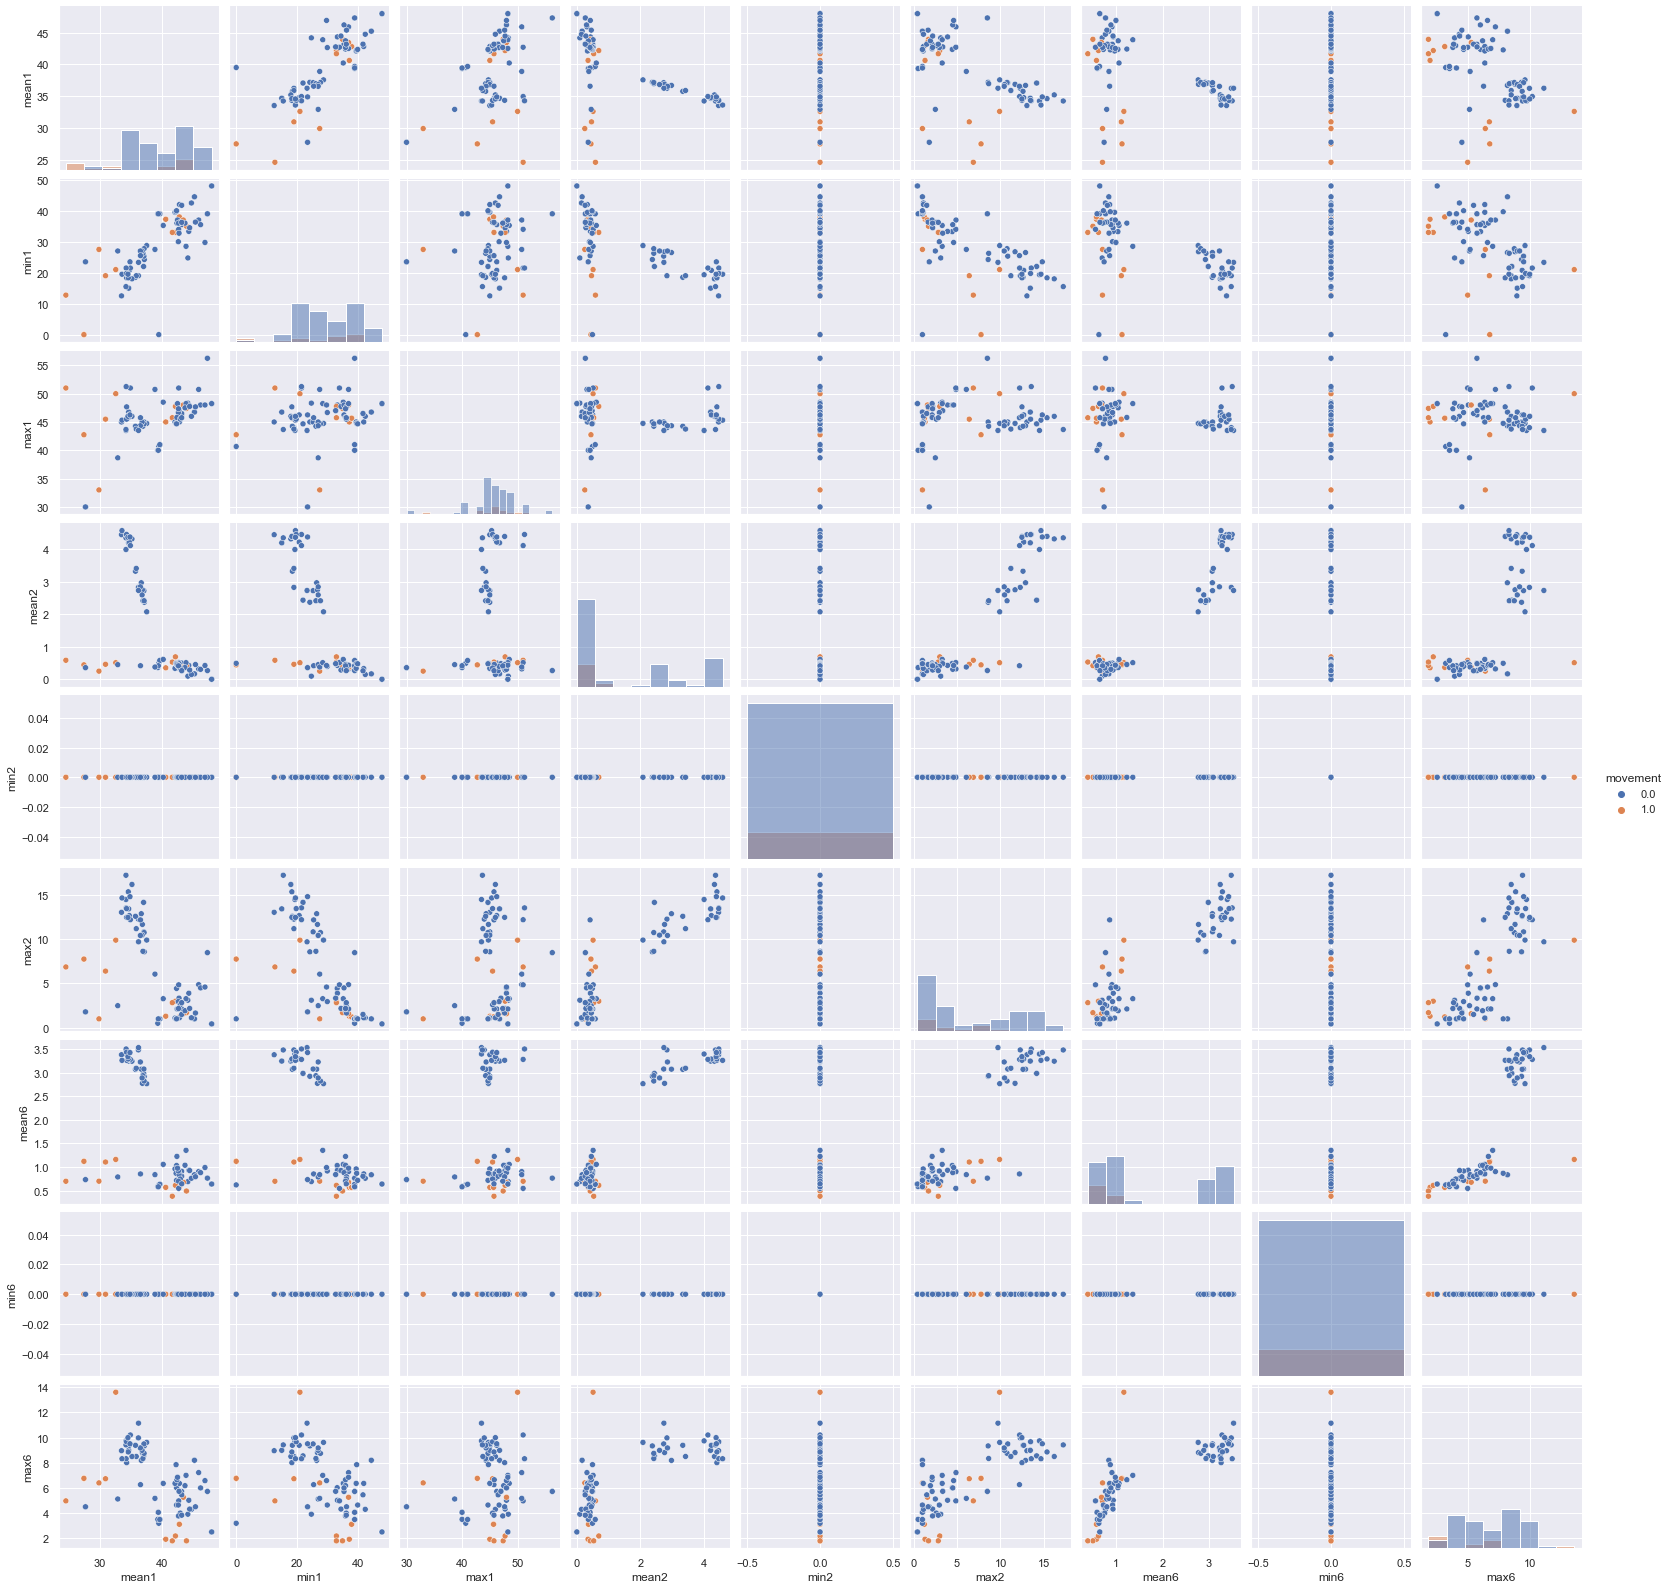

In [26]:
import seaborn as sns
sns.set()
sns.pairplot(df_time_features,hue='movement', diag_kind='hist',vars=['mean1','min1','max1','mean2','min2','max2','mean6','min6','max6'])

In [27]:
def split(a, n):
    k, m = divmod(len(a), n)
    return (a[i*k+min(i, m):(i+1)*k+min(i+1, m)] for i in range(n))

def split_dataset_train(folder_name,parts,xx):
    path = '../data/AReM/'+folder_name
    dataset_list = os.listdir(path)
    start=0
    if(folder_name=='bending1' or folder_name=='bending2'):
        start=3
    else:
        start=4
    split_train_folder=[]
    for j in range(start,len(dataset_list)+1):
        temp = pd.read_csv('../data/AReM/'+folder_name+'/dataset'+str(j)+'.csv', engine='python',header=None,delimiter='[ ,]',usecols=[0,1,2,3,4,5,6], skiprows = [0, 1, 2, 3, 4])
        if(temp.shape[1]!=7):
            temp = pd.read_csv('../data/AReM/'+folder_name+'/dataset'+str(j)+'.csv', header=None,sep=' ',usecols=[0,1,2,3,4,5,6], skiprows = [0, 1, 2, 3, 4])
            temp= pd.DataFrame(temp[0].str.split(',').tolist())
            temp=temp[[0,1,2,3,4,5,6]]
            
        temp = temp[[1,2,3,4,5,6]]
        split_train_dataset=pd.DataFrame()
                
        if len(temp)%parts!=0:
            temp=temp[:-(len(temp)%parts)]
            
        so=(list(split(temp,parts)))
        split_train_dataset=so[0]
        for i in range(1,parts):
            split_train_dataset=pd.concat([split_train_dataset, so[i].reset_index(drop=True)], axis=1)
        split_train_dataset.columns = range(split_train_dataset.shape[1])
        split_train_folder.append(split_train_dataset)
        ft_df=[]
        ft_df = pd.DataFrame(split_train_dataset.describe())
        ft_df = ft_df.iloc[1:,0:]
        ft_df =ft_df.T
        ft_df=(ft_df[['max','min','mean']])
        ft_arr=[]
        ft_arr=ft_df.to_numpy().flatten()
        ft_arr=np.concatenate(([folder_name], ft_arr))
#         if(folder_name=='bending1' or folder_name=='bending2'):
#             ft_arr=np.concatenate((['bending1'], ft_arr))
#         else:
#             ft_arr=np.concatenate(([0], ft_arr))
        xx.loc[len(xx)]=ft_arr
        
#     print(xx)
    
    split_train_folder = pd.concat(split_train_folder, ignore_index=True)
    split_train_folder.insert(0,'movement',folder_name)
#     if(folder_name=='bending1' or folder_name=='bending2'):
#         split_train_folder.insert(0,'movement','bending1')
#     else:
#         split_train_folder.insert(0,'movement','cycling')
    
    return split_train_folder                
    
def split_dataset_test(folder_name,parts,xx):
    path = '../data/AReM/'+folder_name
    dataset_list = os.listdir(path)
    start=0
    if(folder_name=='bending1' or folder_name=='bending2'):
        start=3
    else:
        start=4
    split_test_folder=[]
    for j in range(1,start):
        temp = pd.read_csv('../data/AReM/'+folder_name+'/dataset'+str(j)+'.csv', engine='python',header=None,delimiter='[ ,]',usecols=[0,1,2,3,4,5,6], skiprows = [0, 1, 2, 3, 4])
        if(temp.shape[1]!=7):
            temp = pd.read_csv('../data/AReM/'+folder_name+'/dataset'+str(j)+'.csv', header=None,sep=' ',usecols=[0,1,2,3,4,5,6], skiprows = [0, 1, 2, 3, 4])
            temp= pd.DataFrame(temp[0].str.split(',').tolist())
            temp=temp[[0,1,2,3,4,5,6]]
            
        temp = temp[[1,2,3,4,5,6]]
        split_test_dataset=pd.DataFrame()
                
        if len(temp)%parts!=0:
            temp=temp[:-(len(temp)%parts)]
            
        so=(list(split(temp,parts)))
        split_test_dataset=so[0]
        for i in range(1,parts):
            split_test_dataset=pd.concat([split_test_dataset, so[i].reset_index(drop=True)], axis=1)
        split_test_dataset.columns = range(split_test_dataset.shape[1])
        split_test_folder.append(split_test_dataset)
        ft_df=[]
        ft_df = pd.DataFrame(split_test_dataset.describe())
        ft_df = ft_df.iloc[1:,0:]
        ft_df =ft_df.T
        ft_df=(ft_df[['max','min','mean']])
        ft_arr=[]
        ft_arr=ft_df.to_numpy().flatten()
        ft_arr=np.concatenate(([folder_name], ft_arr))
#         if(folder_name=='bending1' or folder_name=='bending2'):
#             ft_arr=np.concatenate(([1], ft_arr))
#         else:
#             ft_arr=np.concatenate(([0], ft_arr))
        xx.loc[len(xx)]=ft_arr
    
    split_test_folder = pd.concat(split_test_folder, ignore_index=True)
    split_test_folder.insert(0,'movement',folder_name)
#     if(folder_name=='bending1' or folder_name=='bending2'):
#         split_test_folder.insert(0,'movement',1)
#     else:
#         split_test_folder.insert(0,'movement',0)
        
    
    return split_test_folder                
    

In [28]:
def get_labels(curr_label):
    if "bending" in curr_label:
        return 1
    else:
        return 0

In [31]:
path = '../data/AReM'
folder_list=[]
folder_list = os.listdir(path)
folder_list.pop(2)
folder_list.pop(4)

'sensorsPlacement.pdf'

In [32]:
movement_train_list=[]
movement_test_list=[]

In [33]:
def create_train_dataset(xx,parts):
    final_split_train=[]
    for i in folder_list:
        folder_train_data=split_dataset_train(i,parts,xx)
        final_split_train.append(folder_train_data)        
     
    final_split_train = pd.concat(final_split_train, ignore_index=True)
    return final_split_train,xx

def create_test_dataset(xx,parts):
    final_split_test=[]
    for i in folder_list:
        folder_test_data=split_dataset_test(i,parts,xx)
        final_split_test.append(folder_test_data)        
     
    final_split_test = pd.concat(final_split_test, ignore_index=True)
    return final_split_test,xx

# Q2 a ii

In [44]:
head=[]
head.append('movement')
for i in range(2*6):
    head.append('mean'+str(i+1))
    head.append('min'+str(i+1))
    head.append('max'+str(i+1))
 
print(head)
xx=pd.DataFrame(columns=head)
gg,final_split_train=create_train_dataset(xx,2)

['movement', 'mean1', 'min1', 'max1', 'mean2', 'min2', 'max2', 'mean3', 'min3', 'max3', 'mean4', 'min4', 'max4', 'mean5', 'min5', 'max5', 'mean6', 'min6', 'max6', 'mean7', 'min7', 'max7', 'mean8', 'min8', 'max8', 'mean9', 'min9', 'max9', 'mean10', 'min10', 'max10', 'mean11', 'min11', 'max11', 'mean12', 'min12', 'max12']


In [41]:
Y = final_split_train['movement'].apply(get_labels)
X = final_split_train.drop(['movement'], axis=1)
X['movement']=Y

In [49]:
X

,mean1,min1,max1,mean2,min2,max2,mean3,min3,max3,mean4,...,mean10,min10,max10,mean11,min11,max11,mean12,min12,max12,movement
0,46.5,36.5,44.05716666666667,1.5,0.0,0.3810416666666667,29.25,14.25,23.096791666666665,2.74,...,4.44,0.0,0.5011666666666673,38.25,29.0,34.883374999999994,1.5,0.0,0.3883333333333335,1
1,47.75,33.75,43.27887499999999,3.0,0.0,0.6732916666666671,30.0,11.0,23.14125,4.77,...,5.15,0.0,1.1717916666666681,38.5,20.0,30.965708333333335,2.18,0.0,0.5860833333333336,1
2,45.75,33.0,41.62120833333333,2.83,0.0,0.6230833333333335,28.25,3.0,19.08145833333333,6.42,...,2.35,0.0,0.5686666666666672,36.0,26.0,29.635833333333334,1.5,0.0,0.3475000000000003,1
3,48.0,39.0,44.117041666666665,1.3,0.0,0.2500416666666665,27.0,6.25,17.74416666666667,10.03,...,5.21,0.0,0.5757083333333337,26.0,8.0,22.850875,4.06,0.0,0.5438750000000003,1
4,45.0,36.67,43.48620833333334,1.3,0.0,0.37866666666666676,26.33,4.0,16.39725,5.17,...,3.56,0.0,0.6697500000000003,26.0,13.75,21.88204166666667,2.96,0.0,0.5857500000000001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,45.0,19.5,33.3345,11.78,0.0,4.408083333333331,22.75,7.33,15.445333333333334,8.79,...,9.0,0.0,3.1830416666666657,23.33,6.33,15.755958333333332,8.32,0.43,3.2902916666666657,0
65,44.5,20.33,34.03675,13.47,0.0,4.778291666666664,22.0,6.25,15.177083333333334,9.0,...,7.46,0.0,3.160375000000001,23.25,6.33,15.520375,9.67,0.0,3.3214166666666656,0
66,43.33,19.5,34.033875,12.47,0.0,4.574624999999999,22.67,7.0,15.340416666666668,8.34,...,8.22,0.0,3.0319583333333338,21.33,7.0,15.218416666666666,8.64,0.0,3.4322083333333344,0
67,44.0,24.33,34.920791666666666,14.82,0.0,4.17795833333333,24.25,6.67,15.515875000000001,8.34,...,9.9,0.43,3.1762499999999982,23.5,5.5,15.939416666666666,9.51,0.0,3.4186666666666645,0


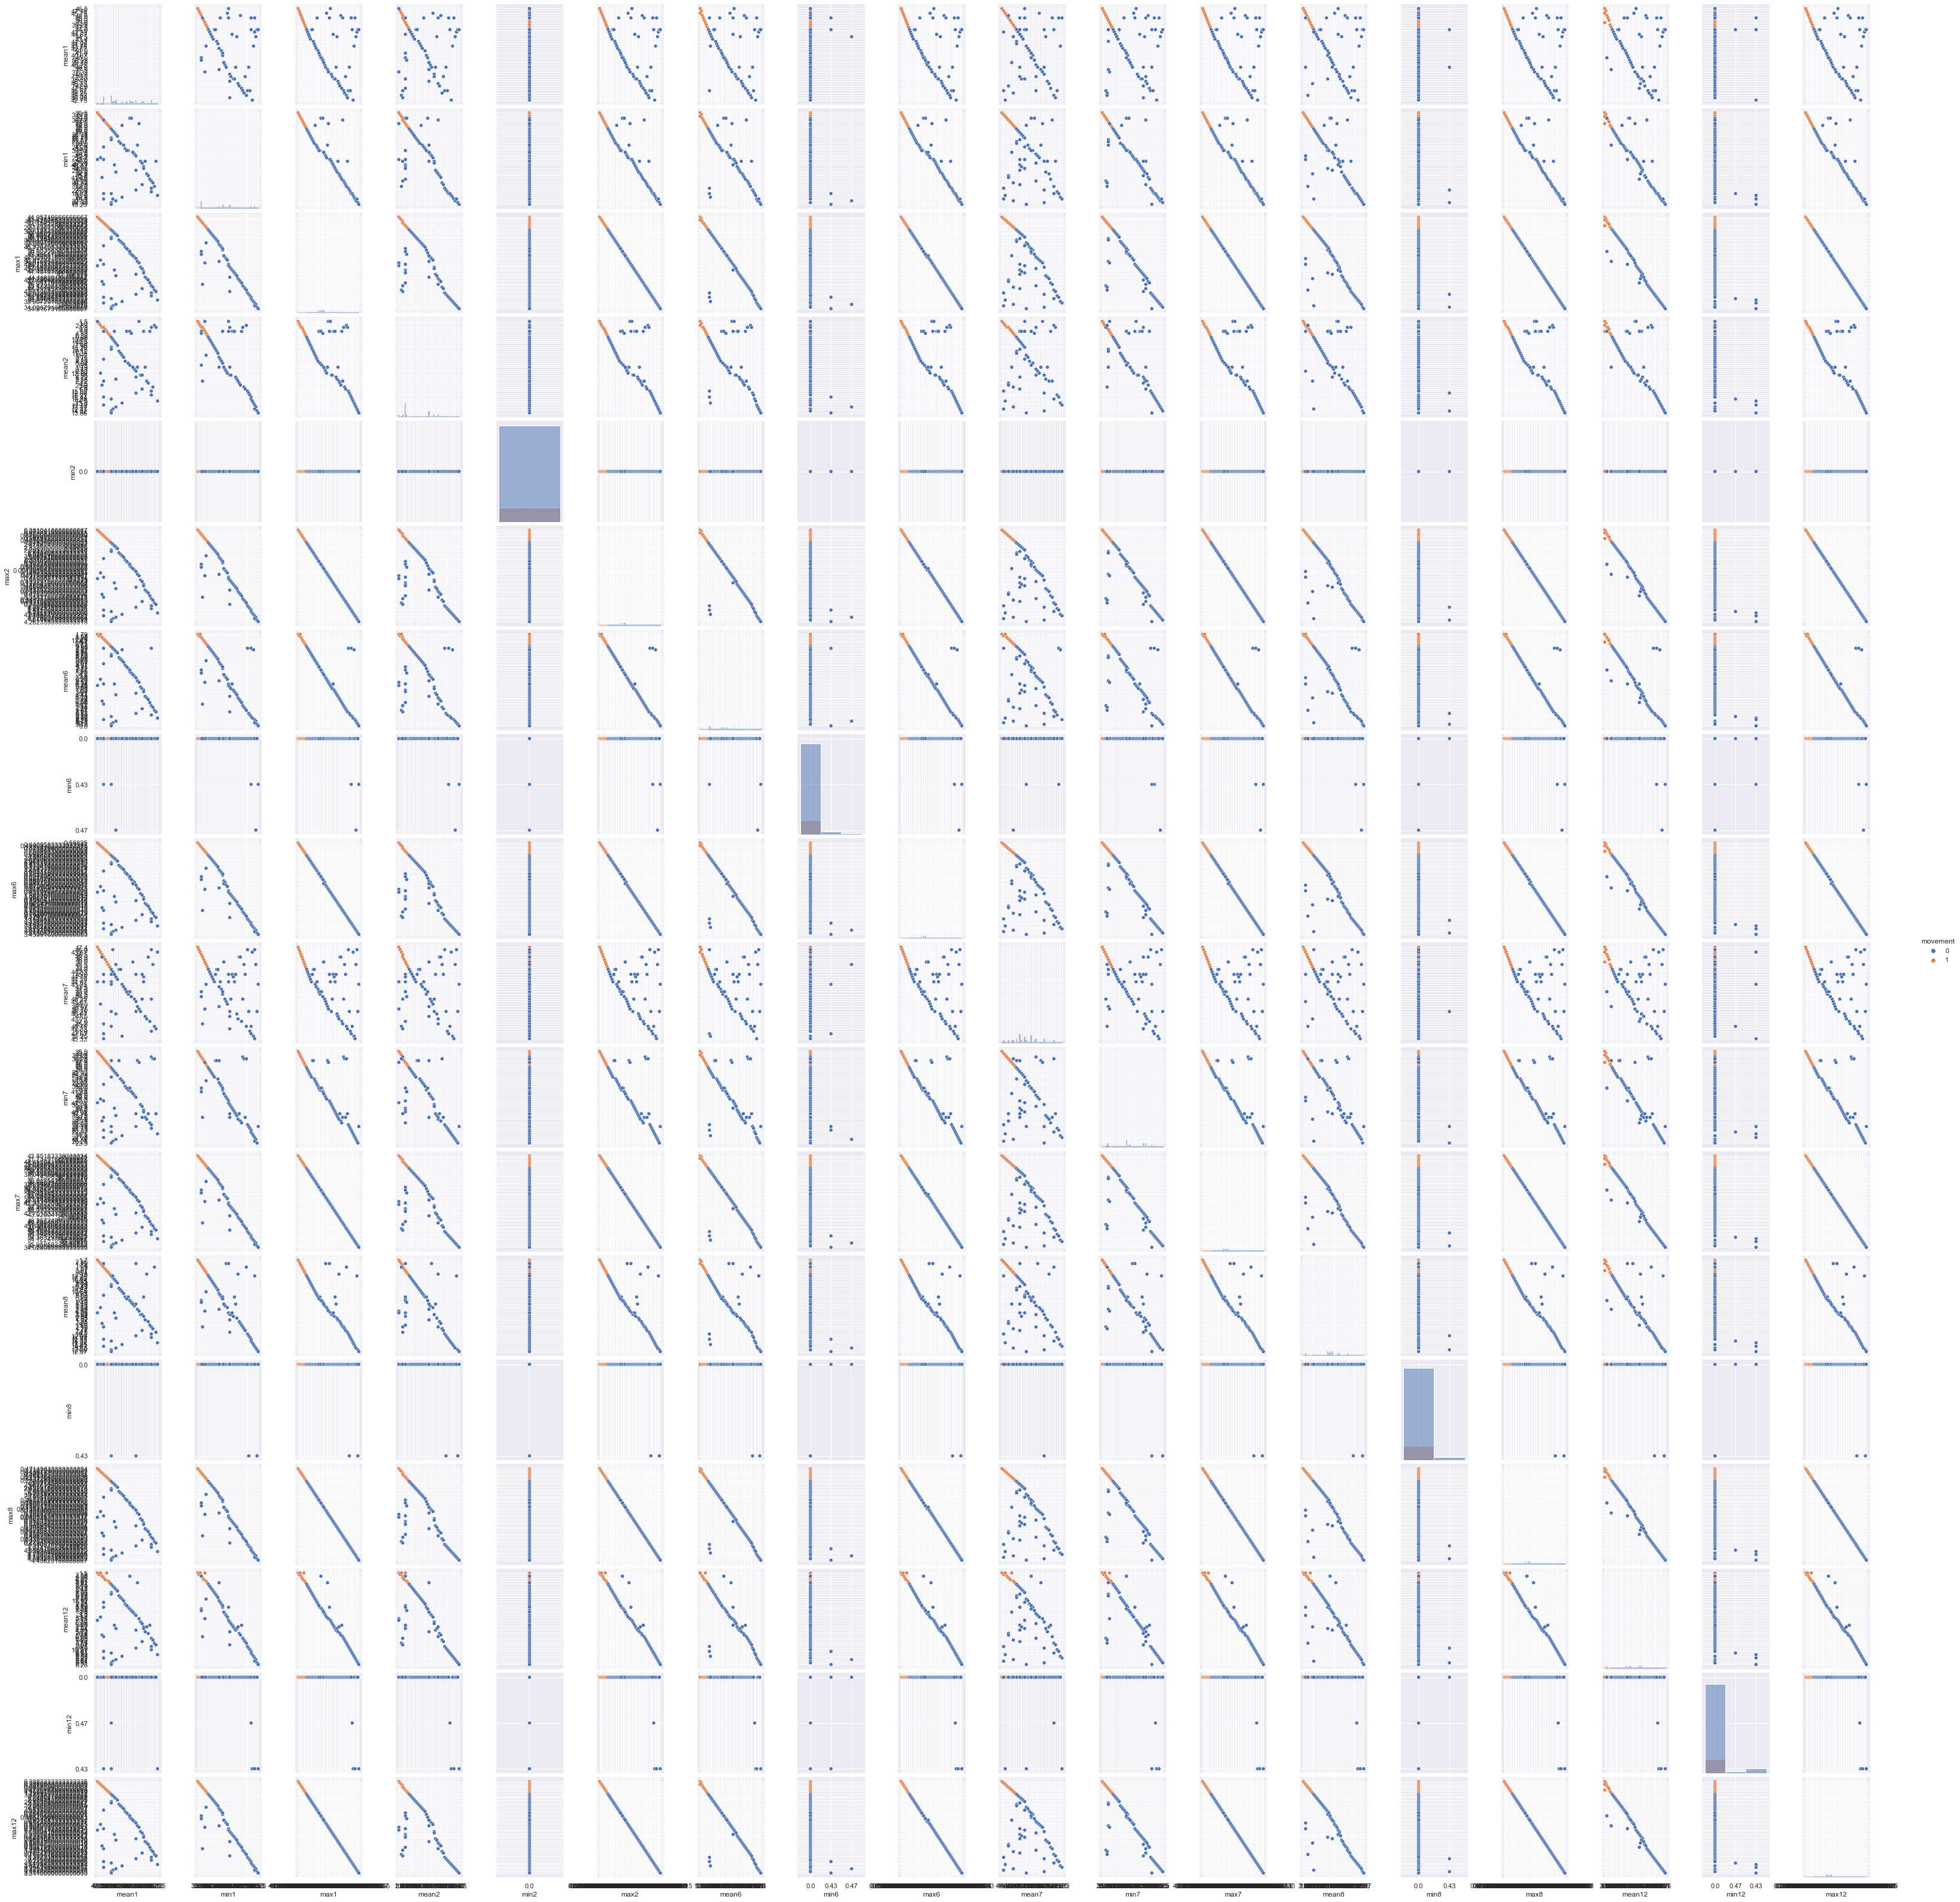

In [48]:
import seaborn as sns
sns.set()
sns.pairplot(X,hue='movement', diag_kind='hist',vars=['mean1','min1','max1','mean2','min2','max2','mean6','min6','max6','mean7','min7','max7','mean8','min8','max8','mean12','min12','max12'])

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LassoCV,LogisticRegressionCV
from sklearn.naive_bayes import GaussianNB,MultinomialNB
from sklearn.feature_selection import RFECV, RFE, chi2
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn import metrics
from sklearn.metrics import confusion_matrix,roc_curve, auc,roc_auc_score
import matplotlib.pyplot as plt
from sklearn import metrics
import statsmodels.api as sm
from scipy import stats
import os
from collections import Counter
import warnings

# Q2 a iii

In [54]:
def get_labels(curr_label):
    if "bending" in curr_label:
        return 1
    else:
        return 0

In [108]:
feature_cols = []
best_cv_score = 0
best_l = 0
best_n_features=0
best_pvalues=[]
for l in range(1,21):
    Y_train = train_instance_list = []
    X_train = train_instance_frame = pd.DataFrame()
    no_of_rows=18*l
    xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
    gg,train_instance_frame=create_train_dataset(xx,l)
    Y_train = train_instance_frame[0].apply(get_labels)
    X_train = train_instance_frame.drop([0], axis=1)
    
    logreg = LogisticRegression(solver='lbfgs', max_iter=500)
    logreg.fit(X_train, Y_train)
    
    rfecv =   RFECV(estimator=logreg, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
    rfecv.fit(X_train, Y_train)
    
    rfecv.cv_results_ ["mean_test_score"]

    cv_score = cross_val_score(rfecv, X_train, Y_train, cv=5, scoring='accuracy')  
    mean_score  =  np.mean(rfecv.cv_results_ ["mean_test_score"])

#     print(rfecv.get_feature_names_out())
    print(mean_score, ' - ',np.mean(rfecv.cv_results_ ["mean_test_score"]))
    c = Counter(rfecv.ranking_)
    n_features=c[1]
    
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_n_features = n_features   
        best_l = l
        best_features=rfecv.get_feature_names_out()
        indices = [ind for ind, ele in enumerate(rfecv.ranking_) if ele == 1]
        scores, pvalues = chi2(X_train,Y_train)
        best_pvalues=pvalues[indices]
    

print("The best value of L for Logistic Regression is :" , best_l )            
print("Optimal cv score for Logistic Regression is :" , best_cv_score)
print("Optimal number of features for Logistic Regression is : " , best_n_features)
print("The Optimal features for Logistic Regression are : ", best_features)
print("Optimal p-values", best_pvalues)

0.9681929181929182  -  0.9681929181929182
0.9470390720390722  -  0.9470390720390722
0.9568172568172568  -  0.9568172568172568
0.9435592185592184  -  0.9435592185592184
0.9335164835164834  -  0.9335164835164834
0.9431013431013431  -  0.9431013431013431
0.9547357404500262  -  0.9547357404500262
0.9374007936507935  -  0.9374007936507935
0.9402726902726902  -  0.9402726902726902
0.9280830280830282  -  0.9280830280830282
0.9317682317682321  -  0.9317682317682321
0.9284442409442412  -  0.9284442409442412
0.9424204001127079  -  0.9424204001127079
0.9337083551369267  -  0.9337083551369267
0.9243508343508345  -  0.9243508343508345
0.9298992673992674  -  0.9298992673992674
0.9415643180349061  -  0.9415643180349061
0.9299891466558134  -  0.9299891466558134
0.9301844354475934  -  0.9301844354475934
0.9317521367521369  -  0.9317521367521369
The best value of L for Logistic Regression is : 1
Optimal cv score for Logistic Regression is : 0.9681929181929182
Optimal number of features for Logistic Regr

# Q2 a iv

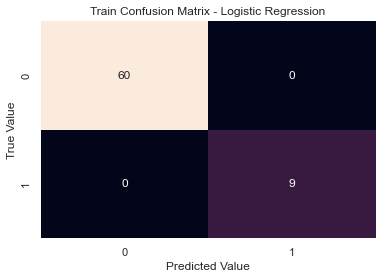

[0.         0.         0.         0.73333333 0.76666667 0.85
 0.88333333 0.95       0.98333333 1.        ]
[0.         0.11111111 1.         1.         1.         1.
 1.         1.         1.         1.        ]


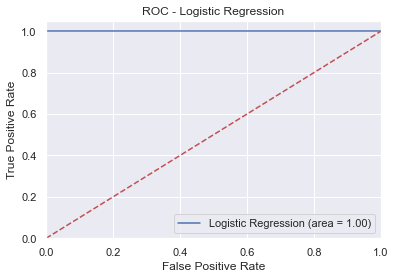

In [109]:
Y_train = train_instance_list = []
X_train = train_instance_frame = pd.DataFrame()
no_of_rows=18*best_l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,train_instance_frame=create_train_dataset(xx,best_l)

Y_train = train_instance_frame[0].apply(get_labels)
X_train = train_instance_frame.drop([0], axis=1)
logreg = LogisticRegression(solver='lbfgs', max_iter=5000)
# logreg.fit(X_train, Y_train)

rfecv =   RFECV(estimator=logreg, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
rfecv.fit(X_train, Y_train)
logreg.fit(X_train, Y_train)
Y_pred =  list(logreg.predict_proba(X_train)[::,1])

conf_mat = confusion_matrix(Y_train, list(map(lambda x: int(x > 0.5), Y_pred)))
ax= plt.subplot()
sns.heatmap(conf_mat, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

roc_auc = roc_auc_score(Y_train, Y_pred)
fp_rate, tp_rate, thresholds = roc_curve(Y_train, Y_pred)
print(fp_rate)
print(tp_rate)
plt.figure()
plt.plot(fp_rate, tp_rate, label='Logistic Regression (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [110]:
print(rfecv.get_feature_names_out())

['x2' 'x8' 'x12' 'x13' 'x14']


In [111]:
rfecv.estimator_.coef_

array([[-0.23808007, -0.57345673,  0.79524072,  0.51316965,  0.47831448]])

In [113]:
X_sum=sm.add_constant(X_train[[2, 8, 12, 13, 14]].astype(float))
logit_model=sm.Logit(Y_train,X_sum)
result=logit_model.fit(maxiter = 20)
result.summary()

         Current function value: 0.000000
         Iterations: 20


C:\Users\Public\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   69
Model:                          Logit   Df Residuals:                       63
Method:                           MLE   Df Model:                            5
Date:                Fri, 03 Mar 2023   Pseudo R-squ.:                   1.000
Time:                        21:54:40   Log-Likelihood:            -9.6100e-06
converged:                      False   LL-Null:                       -26.718
Covariance Type:            nonrobust   LLR p-value:                 2.738e-10
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -183.1009   2.39e+04     -0.008      0.994   -4.71e+04    4.67e+04
2             -0.5714    910.780     -0.001      0.999   -1785.668    1784.525
8             -3.7804   3196.081     -0.001      0.999   -6267.984    6260.423
12             0.3664   9223.262   3.97e-05      1.000   -1.81e+04    1.81e+04
13             5.4109    144.652      0.037      0.970    -278.101     288.923
14             7.7760    620.867      0.013      0.990   -1209.101    1224.653
==============================================================================

Complete Separation: The results show that there iscomplete separation.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

# Q2 a v

C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3

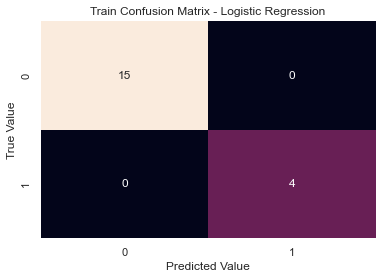

[0. 0. 0. 1.]
[0.   0.25 1.   1.  ]


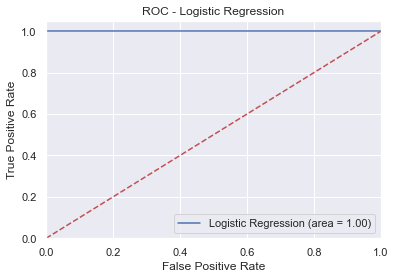

In [115]:

Y_test = test_instance_list = []
X_test = test_instance_frame = pd.DataFrame()
no_of_rows=18*best_l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,test_instance_frame=create_test_dataset(xx,best_l)
Y_test = test_instance_frame[0].apply(get_labels)
X_test = test_instance_frame.drop([0], axis=1)
X_test=X_test[[2, 8, 12, 13, 14]]

logreg = LogisticRegression(solver='lbfgs', max_iter=500)
rfecv =   RFECV(estimator=logreg, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
logreg.fit(X_test, Y_test)
rfecv.fit(X_test, Y_test)
cv_score = cross_val_score(rfecv,X_test, Y_test, cv=5)
Y_pred =  list(logreg.predict_proba(X_test)[::,1])

conf_mat = confusion_matrix(Y_test, list(map(lambda x: int(x > 0.5), Y_pred)))
ax= plt.subplot()
sns.heatmap(conf_mat, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

roc_auc = roc_auc_score(Y_test, Y_pred)
fp_rate, tp_rate, thresholds = roc_curve(Y_test, Y_pred)
plt.figure()
print(fp_rate)
print(tp_rate)
plt.plot(fp_rate, tp_rate, label='Logistic Regression (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [118]:
X_sum=sm.add_constant(X_test.astype(float))
logit_model=sm.Logit(Y_test,X_sum)
result=logit_model.fit(maxiter = 20)
result.summary()

         Current function value: 0.000000
         Iterations: 20


C:\Users\Public\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   19
Model:                          Logit   Df Residuals:                       13
Method:                           MLE   Df Model:                            5
Date:                Fri, 03 Mar 2023   Pseudo R-squ.:                   1.000
Time:                        21:55:35   Log-Likelihood:            -7.9439e-07
converged:                      False   LL-Null:                       -9.7784
Covariance Type:            nonrobust   LLR p-value:                  0.001513
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.4564   5.22e+04      0.000      1.000   -1.02e+05    1.02e+05
2             -1.2281   1889.134     -0.001      0.999   -3703.862    3701.406
8              1.6950   7599.006      0.000      1.000   -1.49e+04    1.49e+04
12           -16.2990   1.69e+04     -0.001      0.999   -3.32e+04    3.32e+04
13            -0.1014   1556.316  -6.51e-05      1.000   -3050.425    3050.222
14             2.3638   4027.901      0.001      1.000   -7892.178    7896.905
==============================================================================

Complete Separation: The results show that there iscomplete separation.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

# Q2 a vi

We know, the classes are well separated from the warnings and cause instability in calculating the logistic regression parameters as there is unequal distribution of positives and negatives.

In [119]:
from imblearn.under_sampling import RandomUnderSampler

# Q2 a vii

In [120]:
feature_cols = []
best_cv_score_sampled = 0
best_l_sampled = 0
best_n_features_sampled=0
best_pvalues_sampled=[]
best_rfecv=0
for l in range(1,21):
    Y_train = train_instance_list = []
    X_train = train_instance_frame = pd.DataFrame()
    no_of_rows=18*l
    xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
    gg,train_instance_frame=create_train_dataset(xx,l)
    Y_train = train_instance_frame[0].apply(get_labels)
    X_train = train_instance_frame.drop([0], axis=1)
    
    rus = RandomUnderSampler()
    X_sampled_train, Y_sampled_train = rus.fit_resample(X_train, Y_train)
    
    logreg = LogisticRegression(solver='lbfgs', max_iter=500)
    rfecv =   RFECV(estimator=logreg, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
    
    rfecv.fit(X_sampled_train, Y_sampled_train)

    cv_score_sampled = cross_val_score(rfecv, X_sampled_train, Y_sampled_train, cv=5, scoring='accuracy')  
    mean_score_sampled  =  np.mean(rfecv.cv_results_ ["mean_test_score"])

    print(rfecv.get_feature_names_out())
    print(mean_score_sampled, ' - ', cv_score_sampled)
    c = Counter(rfecv.ranking_)
    n_features=c[1]
    
    if mean_score_sampled > best_cv_score_sampled:
        best_cv_score_sampled = mean_score_sampled
        best_n_features_sampled = n_features   
        best_l_sampled = l
        best_rfecv=rfecv
        best_features_sampled=rfecv.get_feature_names_out()
        indices = [ind for ind, ele in enumerate(rfecv.ranking_) if ele == 1]
        scores_sampled, pvalues_sampled = chi2(X_sampled_train,Y_sampled_train)
        best_pvalues_sampled=pvalues_sampled[indices]
        

print("The best value of L for Logistic Regression is :" , best_l_sampled )            
print("Optimal cv score for Logistic Regression is :" , best_cv_score_sampled)
print("Optimal number of features for Logistic Regression is : " , best_n_features_sampled)
print("The Optimal features for Logistic Regression are : ", best_features_sampled)
print("Optimal p-values", best_pvalues_sampled)

best_rfecv.estimator_.coef_[0]

['x12' 'x13' 'x14']
0.9203703703703704  -  [1.         1.         1.         0.66666667 1.        ]
['x1' 'x3' 'x12' 'x13' 'x14' 'x19' 'x20' 'x21' 'x31' 'x32' 'x33']
0.7935185185185184  -  [0.75       0.75       1.         0.66666667 0.33333333]
['x1' 'x2' 'x3' 'x6' 'x12' 'x13' 'x14' 'x20' 'x25' 'x30' 'x36' 'x39' 'x43'
 'x44' 'x48' 'x49']
0.8179012345679014  -  [1.         0.75       1.         0.66666667 1.        ]
['x3' 'x12' 'x14' 'x18' 'x30']
0.8215277777777776  -  [1.         1.         1.         0.66666667 0.66666667]
['x12' 'x13' 'x14' 'x38' 'x69' 'x79']
0.8588888888888887  -  [1.         1.         0.75       0.66666667 0.66666667]
['x7' 'x14' 'x30' 'x85' 'x105']
0.8146604938271602  -  [0.75       1.         0.75       1.         0.33333333]
['x0' 'x3' 'x12' 'x13' 'x14' 'x25' 'x30' 'x32' 'x54' 'x61' 'x72' 'x85'
 'x87' 'x93' 'x103' 'x111' 'x121' 'x122']
0.8869047619047621  -  [1.         1.         1.         1.         0.66666667]
['x0' 'x6' 'x12' 'x13' 'x14' 'x21' 'x30' 'x31

array([ 0.21705209,  0.1933169 ,  0.20721152, -0.1412615 ,  0.20888282,
       -0.16712317,  0.17218605])

C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Public\anaconda3

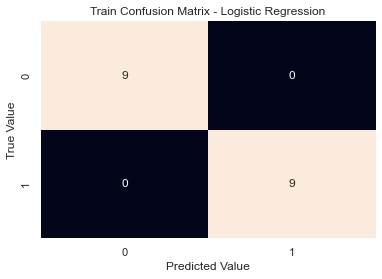

[0. 0. 0. 1.]
[0.         0.11111111 1.         1.        ]


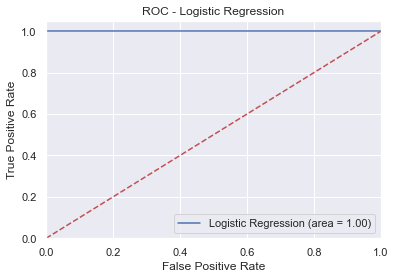

In [124]:
best_l=16
Y_train = train_instance_list = []
X_train = train_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,train_instance_frame=create_train_dataset(xx,l)
Y_train = train_instance_frame[0].apply(get_labels)
X_train = train_instance_frame.drop([0], axis=1)
    
rus = RandomUnderSampler()
X_sampled_train, Y_sampled_train = rus.fit_resample(X_train, Y_train)
   
logreg = LogisticRegression(solver='lbfgs', max_iter=500)
rfecv =   RFECV(estimator=logreg, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
rfecv.fit(X_sampled_train, Y_sampled_train)
logreg.fit(X_sampled_train, Y_sampled_train)
cv_score = cross_val_score(rfecv,X_test, Y_test, cv=5)
Y_pred =  list(logreg.predict_proba(X_sampled_train)[::,1])

conf_mat = confusion_matrix(Y_sampled_train, list(map(lambda x: int(x > 0.5), Y_pred)))
ax= plt.subplot()
sns.heatmap(conf_mat, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

roc_auc = roc_auc_score(Y_sampled_train, Y_pred)
fp_rate, tp_rate, thresholds = roc_curve(Y_sampled_train, Y_pred)
plt.figure()
print(fp_rate)
print(tp_rate)
plt.plot(fp_rate, tp_rate, label='Logistic Regression (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [125]:
rfecv.estimator_.coef_[0]

array([ 0.26872113,  0.28040391, -0.20646724,  0.20164825, -0.24398968,
        0.16594905])

In [133]:
X_sum=sm.add_constant(X_sampled_train[[31, 32, 50, 126, 211, 216, 265]].astype(float))
logit_model=sm.Logit(Y_sampled_train,X_sum)
result=logit_model.fit(maxiter = 15)
result.summary()

         Current function value: 0.000000
         Iterations: 15


C:\Users\Public\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   18
Model:                          Logit   Df Residuals:                       10
Method:                           MLE   Df Model:                            7
Date:                Fri, 03 Mar 2023   Pseudo R-squ.:                   1.000
Time:                        22:23:35   Log-Likelihood:            -3.1304e-06
converged:                      False   LL-Null:                       -12.477
Covariance Type:            nonrobust   LLR p-value:                 0.0007734
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -24.5734   2822.512     -0.009      0.993   -5556.596    5507.449
31             1.4261    330.255      0.004      0.997    -645.861     648.713
32             2.9681    242.573      0.012      0.990    -472.466     478.402
50            -1.3215    229.272     -0.006      0.995    -450.686     448.043
126          -13.0385   1985.381     -0.007      0.995   -3904.314    3878.237
211           -0.1283    340.030     -0.000      1.000    -666.574     666.317
216            6.2780   1727.359      0.004      0.997   -3379.284    3391.840
265           -1.0440    334.406     -0.003      0.998    -656.468     654.380
==============================================================================

Complete Separation: The results show that there iscomplete separation.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

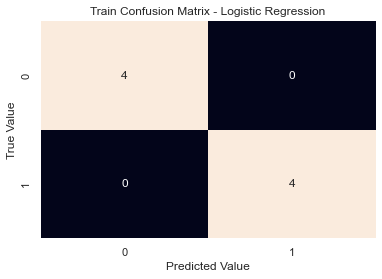

[0. 0. 0. 1.]
[0.   0.25 1.   1.  ]


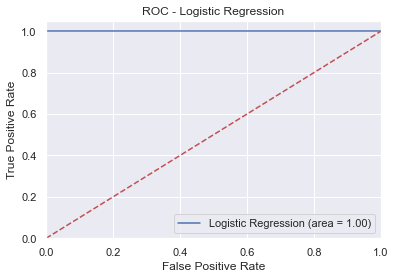

In [134]:
best_l=16
Y_test = test_instance_list = []
X_test = test_instance_frame = pd.DataFrame()
no_of_rows=18*best_l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,test_instance_frame=create_test_dataset(xx,best_l)
Y_test = test_instance_frame[0].apply(get_labels)
X_test = test_instance_frame.drop([0], axis=1)

rus = RandomUnderSampler()
X_sampled_test, Y_sampled_test = rus.fit_resample(X_test, Y_test)

logreg = LogisticRegression(solver='lbfgs', max_iter=500)
logreg.fit(X_sampled_test, Y_sampled_test)
rfecv =   RFECV(estimator=logreg, cv=StratifiedKFold(n_splits=5), scoring='accuracy')

Y_pred =  list(logreg.predict_proba(X_sampled_test)[::,1])

conf_mat = confusion_matrix(Y_sampled_test, list(map(lambda x: int(x > 0.5), Y_pred)))
ax= plt.subplot()
sns.heatmap(conf_mat, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

roc_auc = roc_auc_score(Y_sampled_test, Y_pred)
fp_rate, tp_rate, thresholds = roc_curve(Y_sampled_test, Y_pred)
plt.figure()
print(fp_rate)
print(tp_rate)
plt.plot(fp_rate, tp_rate, label='Logistic Regression (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [136]:
X_sum=sm.add_constant(X_sampled_test[[31, 32, 50, 126, 211, 216, 265]].astype(float))
logit_model=sm.Logit(Y_sampled_test,X_sum)
result=logit_model.fit(maxiter = 20)
result.summary()

         Current function value: 0.000000
         Iterations: 20


C:\Users\Public\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                    8
Model:                          Logit   Df Residuals:                        0
Method:                           MLE   Df Model:                            7
Date:                Fri, 03 Mar 2023   Pseudo R-squ.:                   1.000
Time:                        22:24:32   Log-Likelihood:            -1.4907e-07
converged:                      False   LL-Null:                       -5.5452
Covariance Type:            nonrobust   LLR p-value:                    0.1347
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        122.5944   1.68e+07   7.29e-06      1.000    -3.3e+07     3.3e+07
31            -3.5571   8.48e+05  -4.19e-06      1.000   -1.66e+06    1.66e+06
32             1.8051   1.16e+06   1.56e-06      1.000   -2.27e+06    2.27e+06
50             0.1767   1.11e+06   1.59e-07      1.000   -2.18e+06    2.18e+06
126            0.8662   5.66e+06   1.53e-07      1.000   -1.11e+07    1.11e+07
211            0.0088    1.5e+06   5.88e-09      1.000   -2.95e+06    2.95e+06
216          -21.3235   3.07e+06  -6.95e-06      1.000   -6.01e+06    6.01e+06
265           -0.8576   1.24e+06  -6.92e-07      1.000   -2.43e+06    2.43e+06
==============================================================================

Complete Separation: The results show that there iscomplete separation.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

# Q2 b i

In [140]:
feature_cols = []
best_l1_score = 0
best_l = 0
best_C = 0
best_n_features=0

for l in range(1,21):
    Y_train = train_instance_list = []
    X_train = train_instance_frame = pd.DataFrame()
    no_of_rows=18*l
    xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
    gg,train_instance_frame=create_train_dataset(xx,l)
    Y_train = train_instance_frame[0].apply(get_labels)
    X_train = train_instance_frame.drop([0], axis=1)
    
    scalar = StandardScaler()
    X_train_scalar  = scalar.fit_transform(X_train)
    
    lasso = LogisticRegressionCV(penalty = 'l1',cv=StratifiedKFold(5),solver='liblinear')
    lasso = lasso.fit(X_train_scalar, Y_train)
    cv_score = cross_val_score(lasso, X_train_scalar, Y_train, cv=StratifiedKFold(5), scoring='accuracy')  
    mean_score_l1  =  np.mean(cv_score)

    x=[lasso.coef_[0] != 0]
    
    if mean_score_l1 > best_l1_score:
        best_l1_score = mean_score_l1
        best_l = l
        best_C = lasso.C_[0]
        best_n_features = np.nonzero(x)[1] 
        scores, pvalues = chi2(X_train,Y_train)
        best_pvalues=pvalues[best_n_features]
    

print("The best value of L for Logistic Regression is :" , best_l )   
print("The best value of C for Logistic Regression is :" , best_C )   
print("Optimal cv score for Logistic Regression is :" , best_cv_score)
print("Optimal number of features for Logistic Regression is : " , best_n_features)
print("Optimal p-values for Logistic Regression is : " , best_pvalues)

The best value of L for Logistic Regression is : 1
The best value of C for Logistic Regression is : 0.3593813663804626
Optimal cv score for Logistic Regression is : 0.9681929181929182
Optimal number of features for Logistic Regression is :  [12 13 17]
Optimal p-values for Logistic Regression is :  [3.22181328e-12 2.78982384e-36 2.56916929e-02]


In [144]:
X_sum=sm.add_constant(X_train[[12, 13, 17]].astype(float))
logit_model=sm.Logit(Y_train,X_sum)
result=logit_model.fit(maxiter = 50)
result.summary()

         Current function value: 0.121482
         Iterations: 50


C:\Users\Public\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                   69
Model:                          Logit   Df Residuals:                       65
Method:                           MLE   Df Model:                            3
Date:                Fri, 03 Mar 2023   Pseudo R-squ.:                  0.6863
Time:                        22:36:22   Log-Likelihood:                -8.3822
converged:                      False   LL-Null:                       -26.718
Covariance Type:            nonrobust   LLR p-value:                 5.402e-08
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9239      5.273     -2.261      0.024     -22.260      -1.588
12            -1.0467      0.921     -1.137      0.256      -2.852       0.758
13             0.5372      0.259      2.077      0.038       0.030       1.044
17           -47.5337   5.25e+04     -0.001      0.999   -1.03e+05    1.03e+05
==============================================================================

Possibly complete quasi-separation: A fraction 0.38 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

# Q2 b ii

Logistic Regression with variable selection will perform better as it has higher CV than l1 penalized. However, l1 penalized regression is easier to implement as it avoids variable selection loop thereby reducing computational load

# Q2 c i

In [145]:
feature_cols = []
best_multi_lasso_score = 0
best_multi_l = 0
best_multi_C = 0
best_multi_n_features=0

for l in range(1,21):
    Y_train = train_instance_list = []
    X_train = train_instance_frame = pd.DataFrame()
    no_of_rows=18*l
    xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
    gg,train_instance_frame=create_train_dataset(xx,l)
    Y_train = train_instance_frame[0]
    X_train = train_instance_frame.drop([0], axis=1)
    
    scalar = StandardScaler()
    X_train_scalar  = scalar.fit_transform(X_train)
    
    lasso = LogisticRegressionCV(penalty='l1',  multi_class='multinomial',   cv=3,  solver='saga',max_iter=5000)
    lasso = lasso.fit(X_train_scalar, Y_train)
    cv_score = cross_val_score(lasso, X_train_scalar, Y_train, cv=StratifiedKFold(3), scoring='accuracy')  
    mean_score_multi_lasso  =  np.mean(cv_score)

    x=[lasso.coef_[0] != 0]
    
    if mean_score_multi_lasso > best_multi_lasso_score:
        best_multi_lasso_score = mean_score_multi_lasso
        best_multi_l = l
        best_multi_C = lasso.C_[0]
        best_n_features = np.nonzero(x)[1]
        scores, pvalues = chi2(X_train,Y_train)
        best_pvalues=pvalues[best_n_features]

print("The best value of L for Logistic Regression is :" , best_multi_l )   
print("The best value of C for Logistic Regression is :" , best_multi_C )   
print("Optimal cv score for Logistic Regression is :" , best_multi_lasso_score)
print("Optimal number of features for Logistic Regression is : " , best_n_features)
print("Optimal p-values for Logistic Regression is : " , best_pvalues)

C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Public\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
C:\Users\Public\anaconda3

The best value of L for Logistic Regression is : 1
The best value of C for Logistic Regression is : 2.782559402207126
Optimal cv score for Logistic Regression is : 0.7971014492753623
Optimal number of features for Logistic Regression is :  [ 2 12 13 14]
Optimal p-values for Logistic Regression is :  [2.72888216e-04 3.29744855e-12 9.49538405e-68 1.32198907e-16]


In [146]:
best_multi_l

1

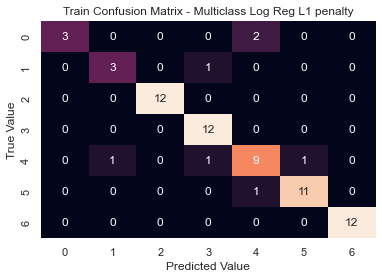

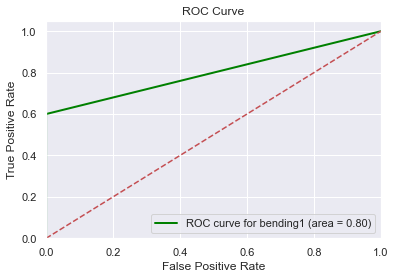

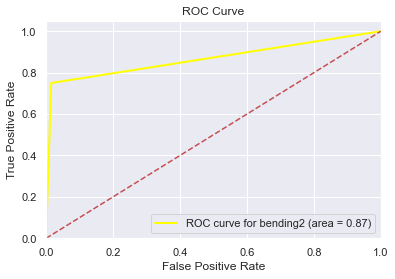

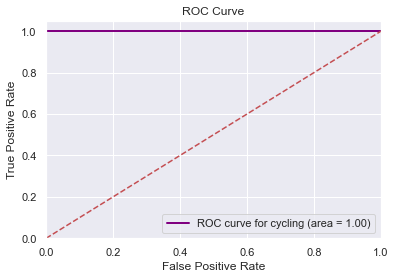

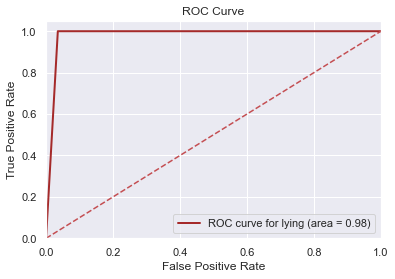

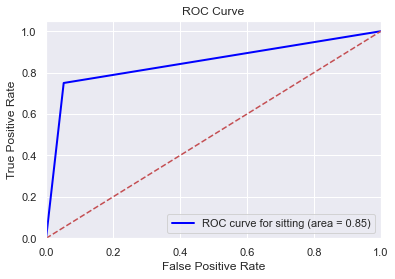

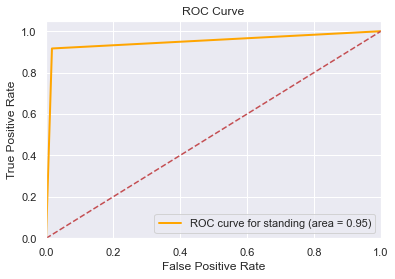

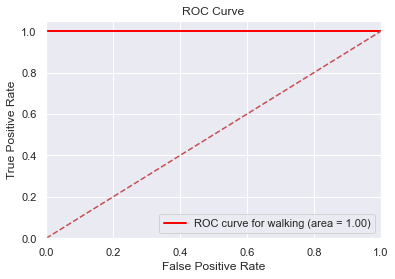

In [148]:
l=best_multi_l
Y_train = train_instance_list = []
X_train = train_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,train_instance_frame=create_train_dataset(xx,l)
Y_train = train_instance_frame[0]
X_train = train_instance_frame.drop([0], axis=1)
    
scalar = StandardScaler()
X_train_scalar  = scalar.fit_transform(X_train)

multi_lasso = LogisticRegression(penalty = 'l1', C = best_C, multi_class='multinomial', solver='saga',max_iter=5000)
multi_lasso = multi_lasso.fit(X_train_scalar, Y_train)
Y_pred = multi_lasso.predict(X_train_scalar)

conf_matrix = confusion_matrix(Y_train, Y_pred)
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Multiclass Log Reg L1 penalty')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

Y_train = label_binarize(Y_train, classes= folder_list)
Y_pred = label_binarize(Y_pred, classes= folder_list)

lw=2
fpr = tpr = roc_auc = dict()
colors =  ['green','yellow','purple','brown','blue','orange','red']
for i in range(0,7):
    fpr, tpr, _ = roc_curve(Y_train[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
    lw=lw, label=f'ROC curve for {folder_list[i]} (area = %0.2f)' %roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

Accuracy for multiclass L-1 Logistic Regression is :  0.9473684210526315


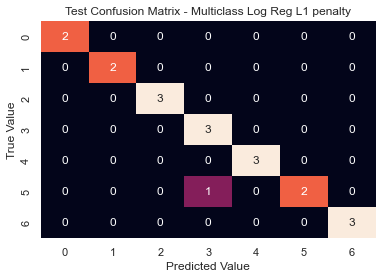

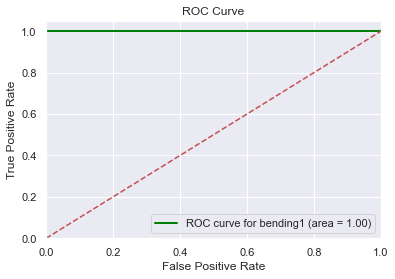

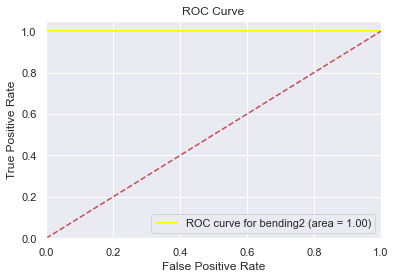

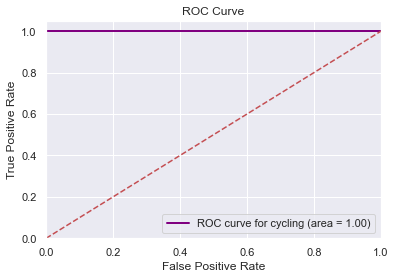

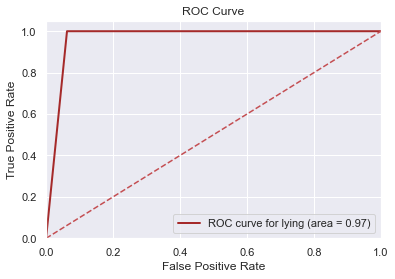

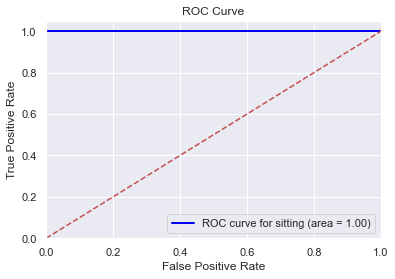

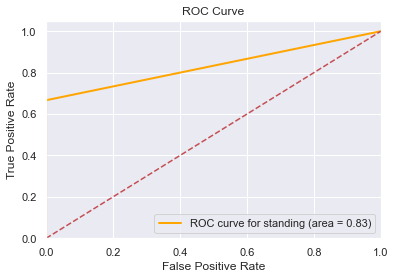

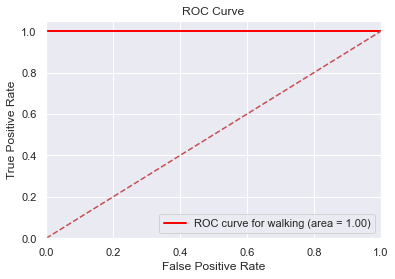

In [150]:
l=best_multi_l
Y_test = test_instance_list = []
X_test = test_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,test_instance_frame=create_test_dataset(xx,l)
Y_test = test_instance_frame[0]
X_test = test_instance_frame.drop([0], axis=1)
    
scalar = StandardScaler()
X_test_scalar = scalar.fit_transform(X_test)

Y_pred = multi_lasso.predict(X_test_scalar)

logistic_multinomial_accuracy = metrics.accuracy_score(Y_test, Y_pred)
print("Accuracy for multiclass L-1 Logistic Regression is : ", logistic_multinomial_accuracy )

conf_matrix = confusion_matrix(Y_test, Y_pred)
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, cbar= False, ax = ax);
plt.title('Test Confusion Matrix - Multiclass Log Reg L1 penalty')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

Y_test = label_binarize(Y_test, classes= folder_list)
Y_pred = label_binarize(Y_pred, classes= folder_list)

lw=2
fpr = tpr = roc_auc = dict()
colors = ['green','yellow','purple','brown','blue','orange','red']
for i in range(0,7):
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
    lw=lw, label=f'ROC curve for {folder_list[i]} (area = %0.2f)' %roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Q2 c ii

In [152]:
best_gaussian_l = 0
best_gaussian_cv_score = 0
for l in range(1, 21):
    Y_train = train_instance_list = []
    X_train = train_instance_frame = pd.DataFrame()
    no_of_rows=18*l
    xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
    gg,train_instance_frame=create_train_dataset(xx,l)
    Y_train = train_instance_frame[0]
    X_train = train_instance_frame.drop([0], axis=1)
    
    nbgaussian = GaussianNB()
    nbgaussian = nbgaussian.fit(X_train, Y_train)
    cv_score = cross_val_score(
        nbgaussian, X_train, Y_train, cv=3, scoring='accuracy')
    mean_score = np.mean(cv_score)
    if mean_score > best_gaussian_cv_score:
        best_gaussian_cv_score = mean_score
        best_gaussian_l = l

print("The best L-value for Multiclass Gaussian Naive Bayes is : ", best_gaussian_l)
print("Optimal CV score for Multiclass Gaussian Naive Bayes is: ", best_gaussian_cv_score)

The best L-value for Multiclass Gaussian Naive Bayes is :  1
Optimal CV score for Multiclass Gaussian Naive Bayes is:  0.8405797101449276


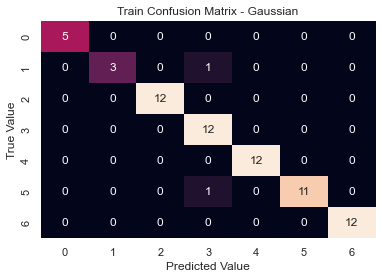

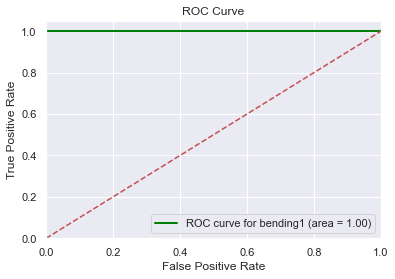

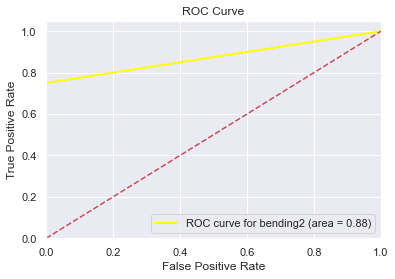

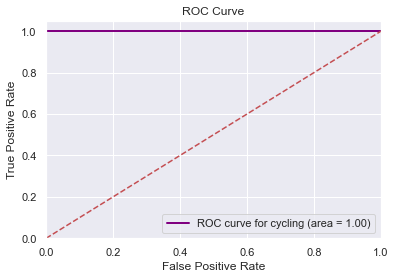

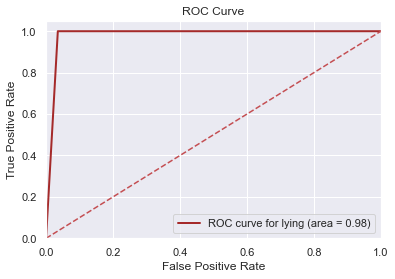

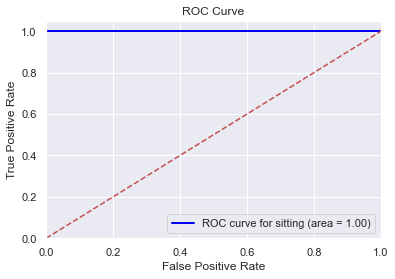

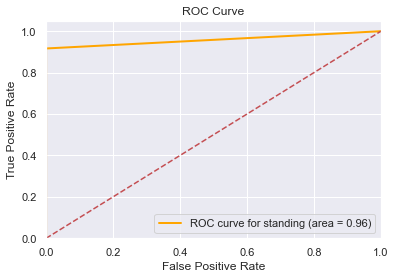

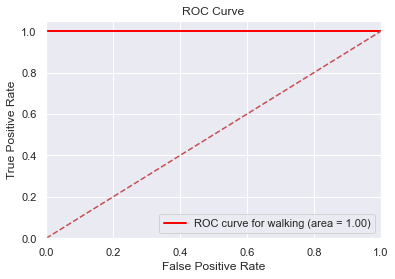

In [155]:
l=best_gaussian_l
Y_train = train_instance_list = []
X_train = train_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,train_instance_frame=create_train_dataset(xx,l)
Y_train = train_instance_frame[0]
X_train = train_instance_frame.drop([0], axis=1)

nbgaussian = GaussianNB()
nbgaussian = nbgaussian.fit(X_train, Y_train)

Y_pred = nbgaussian.predict(X_train)

conf_matrix = confusion_matrix(Y_train, Y_pred)
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Gaussian')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

Y_train = label_binarize(Y_train, classes= folder_list)
Y_pred = label_binarize(Y_pred, classes= folder_list)

lw=2
fpr = tpr = roc_auc = dict()
colors =  ['green','yellow','purple','brown','blue','orange','red']
for i in range(0,7):
    fpr, tpr, _ = roc_curve(Y_train[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
    lw=lw, label=f'ROC curve for {folder_list[i]} (area = %0.2f)' %roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

Accuracy for multiclass naive bayes(Gaussian Prior) is :  0.9473684210526315


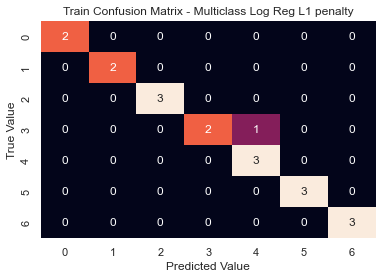

19
19


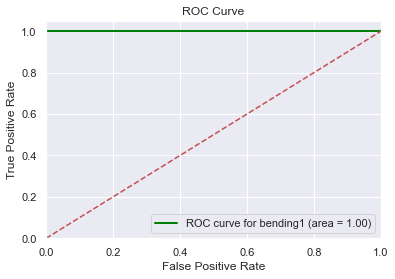

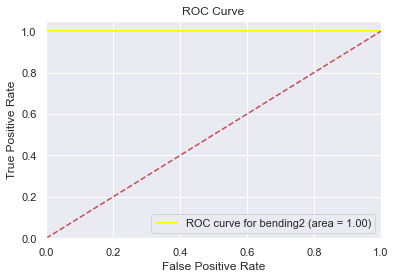

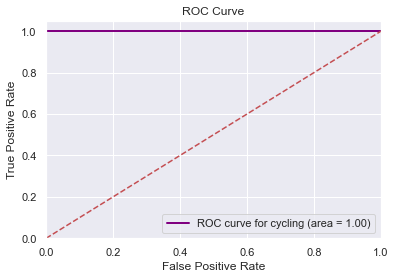

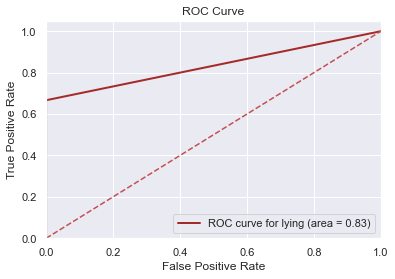

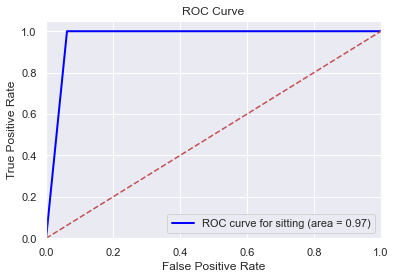

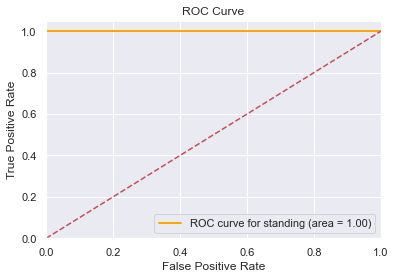

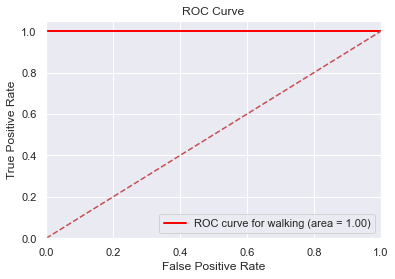

In [154]:
l=best_gaussian_l
Y_test = test_instance_list = []
X_test = test_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,test_instance_frame=create_test_dataset(xx,l)
Y_test = test_instance_frame[0]
X_test = test_instance_frame.drop([0], axis=1)

Y_pred = nbgaussian.predict(X_test)

gaussian_accuracy = metrics.accuracy_score(Y_test, Y_pred)
print("Accuracy Multiclass Gaussian Naive Bayes is : ", gaussian_accuracy )

conf_matrix = confusion_matrix(Y_test, Y_pred)
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, cbar= False, ax = ax);
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

Y_test = label_binarize(Y_test, classes= folder_list)
Y_pred = label_binarize(Y_pred, classes= folder_list)

lw=2
fpr = tpr = roc_auc = dict()
print(len(Y_test))
print(len(Y_pred))
colors =  ['green','yellow','purple','brown','blue','orange','red']
for i in range(0,7):
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
    lw=lw, label=f'ROC curve for {folder_list[i]} (area = %0.2f)' %roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

In [156]:
best_multinomial_l = 0
best_multinomial_cv_score = 0
for l in range(1, 21):
    Y_train = train_instance_list = []
    X_train = train_instance_frame = pd.DataFrame()
    no_of_rows=18*l
    xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
    gg,train_instance_frame=create_train_dataset(xx,l)
    Y_train = train_instance_frame[0]
    X_train = train_instance_frame.drop([0], axis=1)
    
    multinomialNB = MultinomialNB()
    multinomialNB = multinomialNB.fit(X_train, Y_train)
    cv_score = cross_val_score(
        multinomialNB, X_train, Y_train, cv=3, scoring='accuracy')
    mean_score = np.mean(cv_score)
    if mean_score > best_multinomial_cv_score:
        best_multinomial_cv_score = mean_score
        best_multinomial_l = l

print("The best L-value for Multiclass Multinomial Naive Bayes is : : ", best_multinomial_l)
print("Optimal CV score for Multiclass Multinomial Naive Bayes is: ", best_multinomial_cv_score)

The best L-value for Multiclass Multinomial Naive Bayes is : :  4
Optimal CV score for Multiclass Multinomial Naive Bayes is:  0.7826086956521738


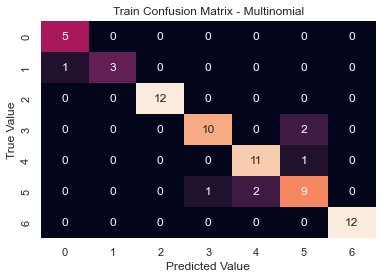

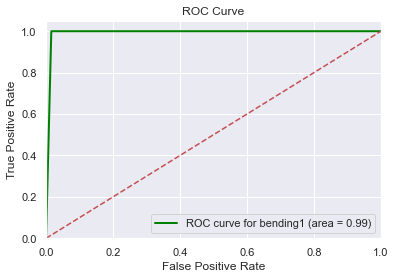

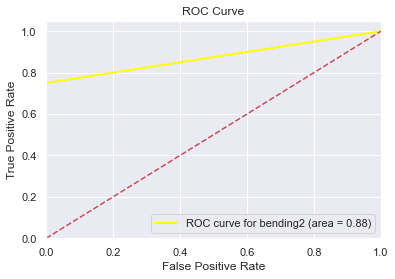

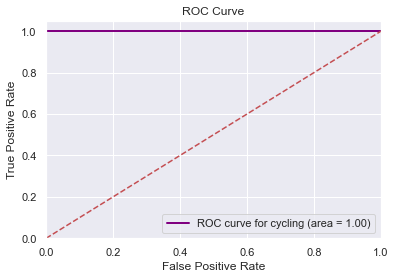

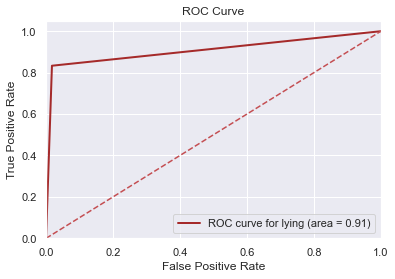

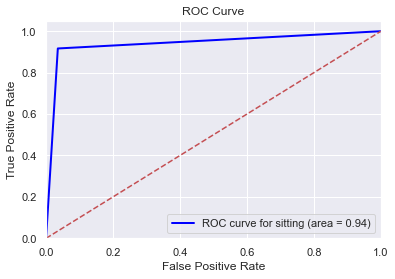

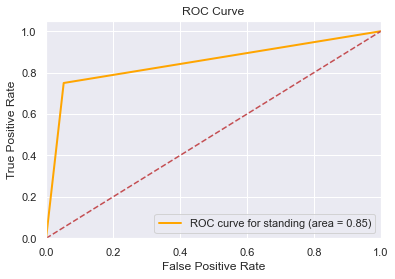

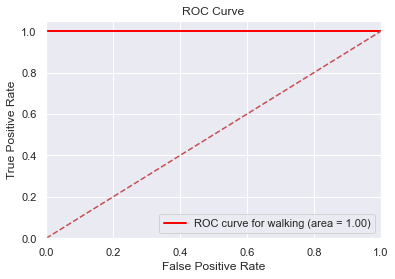

In [157]:
l=best_multinomial_l
Y_train = train_instance_list = []
X_train = train_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,train_instance_frame=create_train_dataset(xx,l)
Y_train = train_instance_frame[0]
X_train = train_instance_frame.drop([0], axis=1)

multinomialNB = MultinomialNB()
multinomialNB = multinomialNB.fit(X_train, Y_train)

Y_pred = multinomialNB.predict(X_train)


conf_matrix = confusion_matrix(Y_train, Y_pred)
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, cbar= False, ax = ax);
plt.title('Train Confusion Matrix - Multinomial')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

Y_train = label_binarize(Y_train, classes= folder_list)
Y_pred = label_binarize(Y_pred, classes= folder_list)


lw=2
fpr = tpr = roc_auc = dict()
colors =  ['green','yellow','purple','brown','blue','orange','red']
for i in range(0,7):
    fpr, tpr, _ = roc_curve(Y_train[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
    lw=lw, label=f'ROC curve for {folder_list[i]} (area = %0.2f)' %roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

Accuracy for Multinomial Naive Bayes:  0.7368421052631579


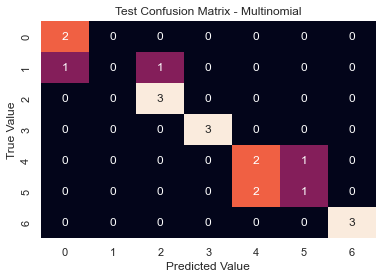

19
19


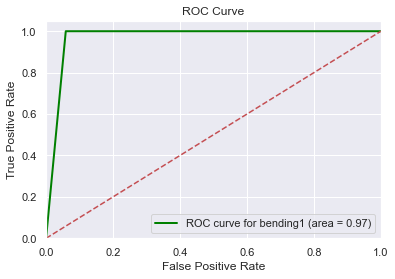

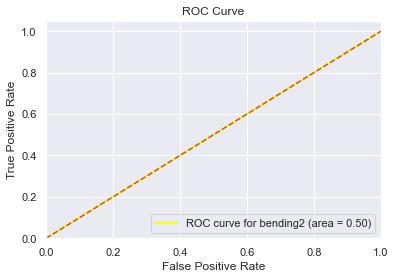

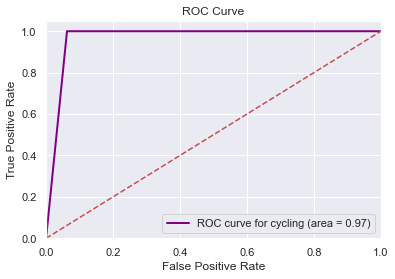

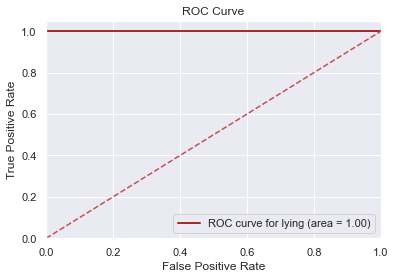

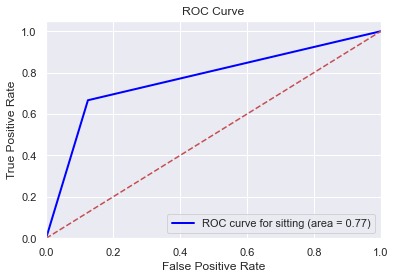

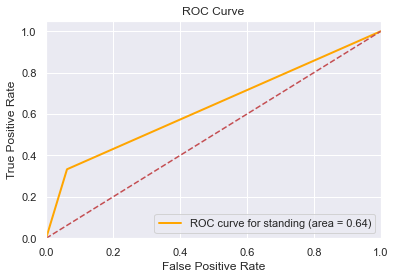

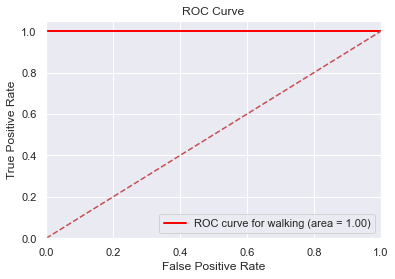

In [158]:
l=best_multinomial_l
Y_test = test_instance_list = []
X_test = test_instance_frame = pd.DataFrame()
no_of_rows=18*l
xx=pd.DataFrame(columns=list(range(no_of_rows+1)))
gg,test_instance_frame=create_test_dataset(xx,l)
Y_test = test_instance_frame[0]
X_test = test_instance_frame.drop([0], axis=1)

Y_pred = multinomialNB.predict(X_test)

multinomial_accuracy = metrics.accuracy_score(Y_test, Y_pred)
print("Accuracy for Multinomial Naive Bayes: ", multinomial_accuracy )

conf_matrix = confusion_matrix(Y_test, Y_pred)
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, cbar= False, ax = ax);
plt.title('Test Confusion Matrix - Multinomial')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.show()

Y_test = label_binarize(Y_test, classes= folder_list)
Y_pred = label_binarize(Y_pred, classes= folder_list)

lw=2
fpr = tpr = roc_auc = dict()
print(len(Y_test))
print(len(Y_pred))
colors =  ['green','yellow','purple','brown','blue','orange','red']
for i in range(0,7):
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
    lw=lw, label=f'ROC curve for {folder_list[i]} (area = %0.2f)' %roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Q3

We get the discriminant function as 
delta(x) = log(pi k) - log(sigma k) - (mu k)^2/(2* (sigma k)^2) + x

This is quadratic and hence Bayes Classifier is not linear in x

# Q4

We have pi yes=0.8, pi no=0.2, mu yes=10, mu no=0 and variance = 36. 
From Bayes theorem we get p yes(4) = 0.75186